In [31]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [32]:
train_dir = "FaceShape Dataset/training_set"

In [33]:
import os

for folder in os.listdir(train_dir):
    path = os.path.join(train_dir, folder)

    if os.path.isdir(path):
        print(folder, ":", len(os.listdir(path)))

Heart : 590
Oblong : 590
Oval : 590
Round : 590
Square : 590


In [34]:
train_gen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

train_data = train_gen.flow_from_directory(
    train_dir,
    target_size=(128,128),
    batch_size=32,
    class_mode="sparse",
    subset="training",
    shuffle=True
)

Found 2360 images belonging to 5 classes.


In [35]:

val_data = train_gen.flow_from_directory(
    train_dir,
    target_size=(128,128),
    batch_size=32,
    class_mode="sparse",
    subset="validation",
    shuffle=False
)

Found 590 images belonging to 5 classes.


In [36]:
print("Class Labels:", train_data.class_indices)

Class Labels: {'Heart': 0, 'Oblong': 1, 'Oval': 2, 'Round': 3, 'Square': 4}


In [47]:
model = Sequential([

    Conv2D(32,(3,3),activation="relu",input_shape=(128,128,3)),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(32,(3,3),activation="relu"),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(128,(3,3),activation="relu"),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(128,(3,3),activation="relu"),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128,activation="relu"),
    Dropout(0.5),

    Dense(128,activation="relu"),
    Dropout(0.3),

    Dense(5,activation="softmax")

])

In [48]:
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [49]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

In [50]:
checkpoint = ModelCheckpoint(
    "face_shape.keras",
    monitor="val_accuracy",
    save_best_only=True
)

In [53]:
history = model.fit(
    train_data,
    epochs=10,
    validation_data=val_data,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 48s 650ms/step - accuracy: 0.2419 - loss: 1.6237 - val_accuracy: 0.2051 - val_loss: 1.7270
Epoch 2/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 43s 573ms/step - accuracy: 0.2661 - loss: 1.5893 - val_accuracy: 0.1949 - val_loss: 1.7576
Epoch 3/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 46s 617ms/step - accuracy: 0.2725 - loss: 1.5785 - val_accuracy: 0.2356 - val_loss: 1.7343
Epoch 4/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 46s 626ms/step - accuracy: 0.2737 - loss: 1.5822 - val_accuracy: 0.2559 - val_loss: 1.6580
Epoch 5/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 79s 578ms/step - accuracy: 0.2903 - loss: 1.5612 - val_accuracy: 0.2814 - val_loss: 1.6043
Epoch 6/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 83s 587ms/step - accuracy: 0.3047 - loss: 1.5600 - val_accuracy: 0.3017 - val_loss: 1.5568
Epoch 7/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 113s 1s/step - accuracy: 0.2983 - loss: 1.5527 - val_accuracy: 0.3390 - val_loss: 1.5239
Epoch 8/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 69s 935ms/step - accuracy: 0.3237 - loss: 1.5373 - val_accura

In [54]:
loss, accuracy = model.evaluate(train_data)

print("Test Accuracy :", accuracy)

74/74 ━━━━━━━━━━━━━━━━━━━━ 33s 444ms/step - accuracy: 0.3919 - loss: 1.4401
Test Accuracy : 0.3919491469860077


Text(0.5, 1.0, 'Accuracy')

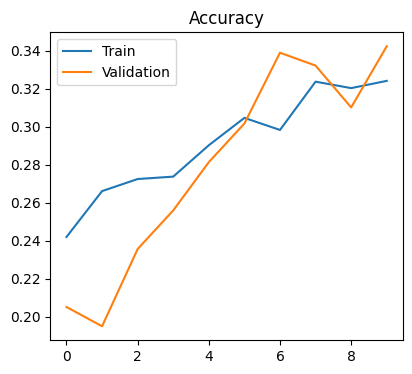

In [55]:
#plotting accuracy
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.legend(['Train','Validation'])

plt.title("Accuracy")

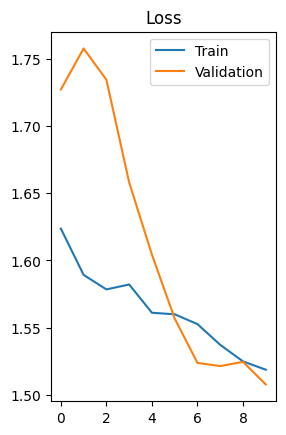

In [56]:
#plotting loss
plt.subplot(1,2,2)

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.legend(['Train','Validation'])

plt.title("Loss")

plt.show()

In [59]:
#testing one image
img_path="test.png"

img = image.load_img(img_path, target_size=(128,128))
img_array=image.img_to_array(img)/255.0


img_array=np.expand_dims(img_array,axis=0)

In [60]:
prediction=model.predict(img_array)
predicted_class=np.argmax(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 327ms/step


In [61]:
class_names=list(train_data.class_indices.keys())
print(class_names[predicted_class])

Square


In [62]:
model.save("face_shape.keras")